## Fourier Transforms

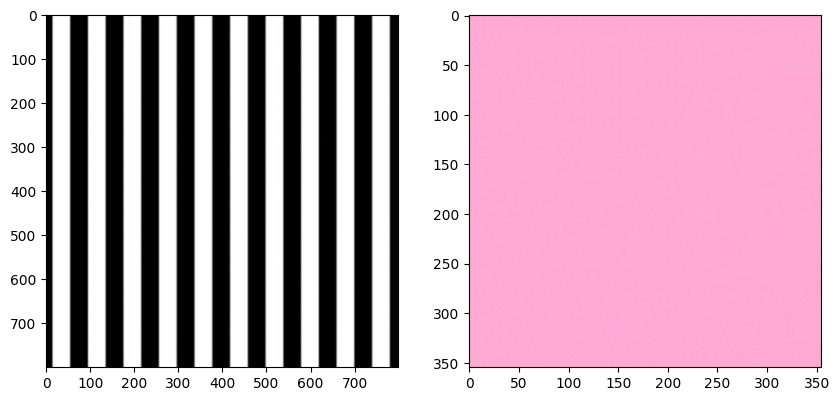

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline

image_stripes = cv2.imread('images/stripes.jpg')
image_stripes = cv2.cvtColor(image_stripes, cv2.COLOR_BGR2RGB)

image_solid = cv2.imread('images/pink_solid.jpg')
image_solid = cv2.cvtColor(image_solid, cv2.COLOR_BGR2RGB)

f, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.imshow(image_stripes)
ax2.imshow(image_solid)

In [2]:
gray_stripes = cv2.cvtColor(image_stripes, cv2.COLOR_RGB2GRAY)
gray_solid = cv2.cvtColor(image_solid, cv2.COLOR_RGB2GRAY)

norm_stripes = gray_stripes/255.0
norm_solid = gray_solid/255.0

def ft_image(norm_image):
    f = np.fft.fft2(norm_image)
    fshift = np.fft.fftshift(f)
    frequency_tx = 20*np.log(np.abs(fshift))
    
    return frequency_tx


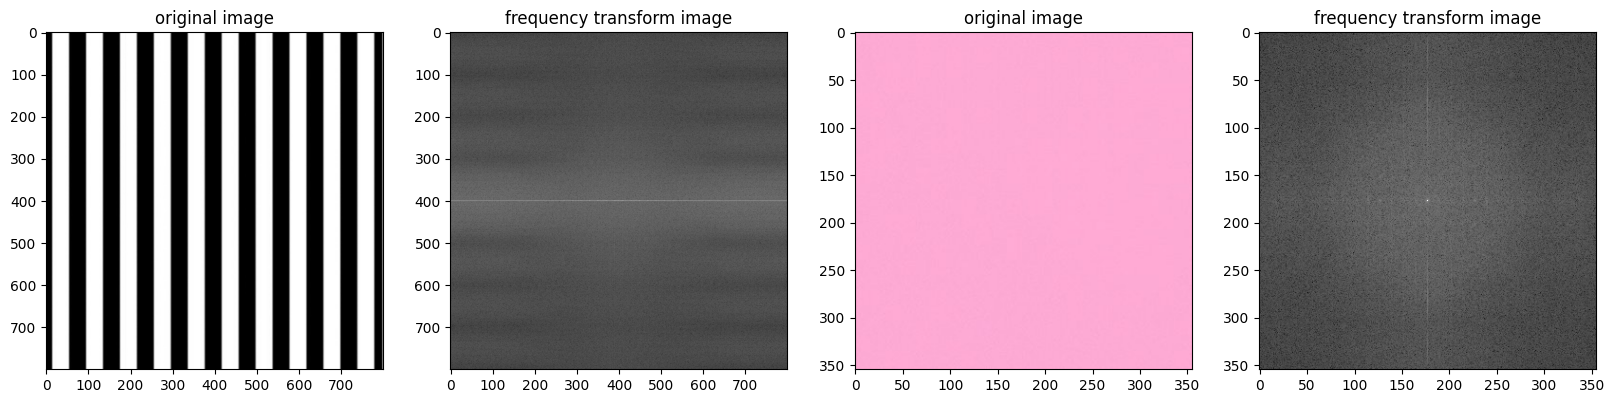

In [3]:
f_stripes = ft_image(norm_stripes)
f_solid = ft_image(norm_solid)

f, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4, figsize=(20,10))

ax1.set_title('original image')
ax1.imshow(image_stripes)
ax2.set_title('frequency transform image')
ax2.imshow(f_stripes, cmap='gray')

ax3.set_title('original image')
ax3.imshow(image_solid)
ax4.set_title('frequency transform image')
ax4.imshow(f_solid, cmap='gray')


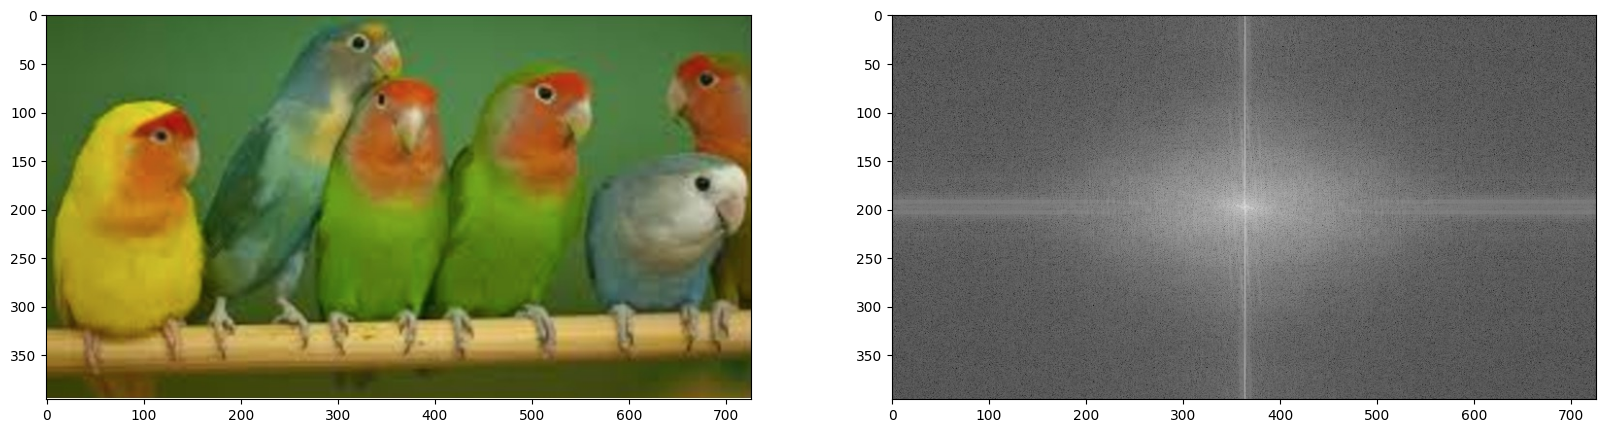

In [4]:
image = cv2.imread('images/birds.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
norm_image = gray/255.0

f_image = ft_image(norm_image)

f, (ax1,ax2) = plt.subplots(1, 2, figsize=(20,10))

ax1.imshow(image)
ax2.imshow(f_image, cmap='gray')

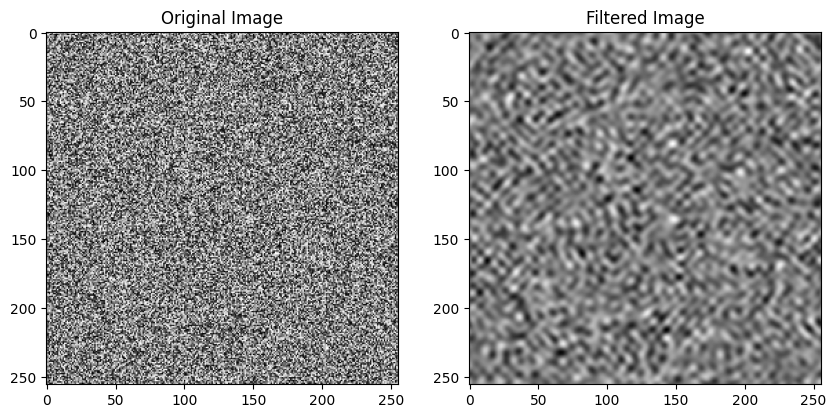

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def low_pass_filter(image, threshold=10):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    
    # Create a mask with True values below a threshold distance from the center
    rows, cols = image.shape
    crow, ccol = rows//2, cols//2  # center
    mask = np.zeros((rows, cols), np.uint8)
    mask[crow-threshold:crow+threshold, ccol-threshold:ccol+threshold] = 1
    
    # mask and inverse FFT
    fshift = fshift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    
    return img_back

image_normalized = np.random.rand(256, 256)  
filtered_image = low_pass_filter(image_normalized, threshold=30)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(image_normalized, cmap='gray'), plt.title('Original Image')
plt.subplot(122), plt.imshow(filtered_image, cmap='gray'), plt.title('Filtered Image')
plt.show()
